In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [7]:
train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [8]:
print(train[train['GarageType'].isnull()]['GarageArea'].sum())
print(train[train['FireplaceQu'].isnull()]['Fireplaces'].sum())

0
0


In [9]:
numeric_df = train.select_dtypes(include='number')
corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
corr 

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

Text(0.5, 1.0, 'log1p(SalePrice)')

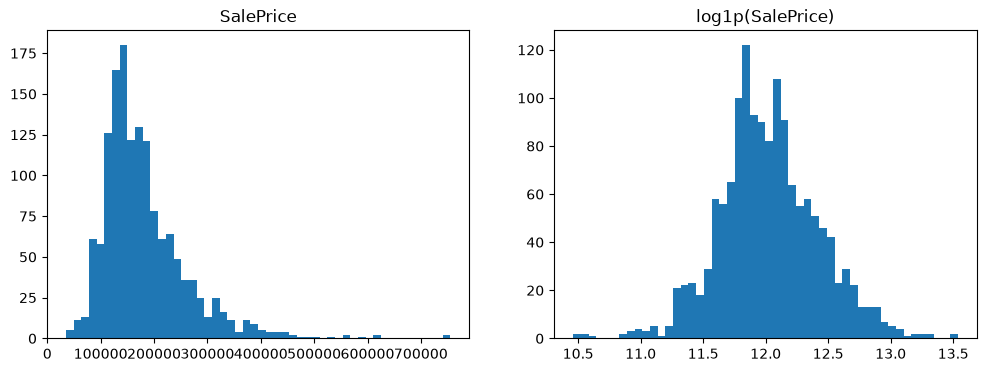

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['SalePrice'], bins=50)
axes[0].set_title('SalePrice')

axes[1].hist(np.log1p(train['SalePrice']), bins=50)
axes[1].set_title('log1p(SalePrice)')

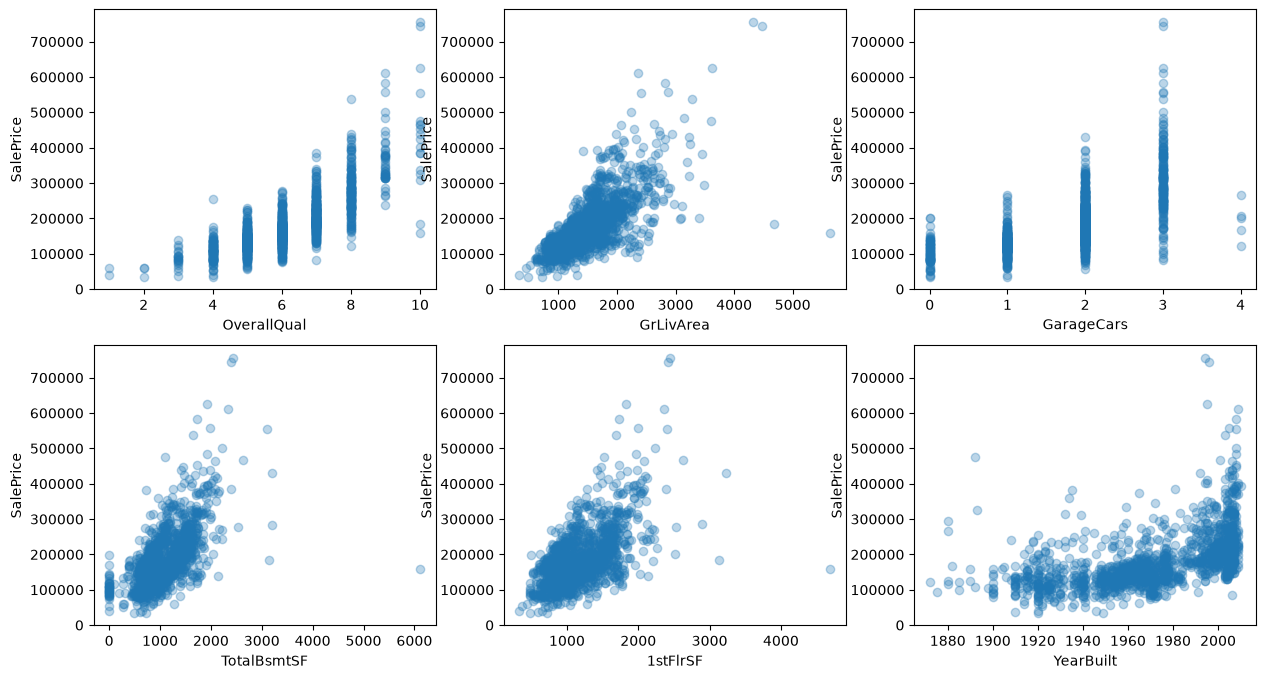

In [14]:
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(train[col], train['SalePrice'], alpha=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')

In [15]:
train[train['GrLivArea'] > 4000][['GrLivArea', 'SalePrice', 'OverallQual']]

,GrLivArea,SalePrice,OverallQual
523,4676,184750,10
691,4316,755000,10
1182,4476,745000,10
1298,5642,160000,10


In [16]:
train = train.drop([523, 1298]).reset_index(drop=True)

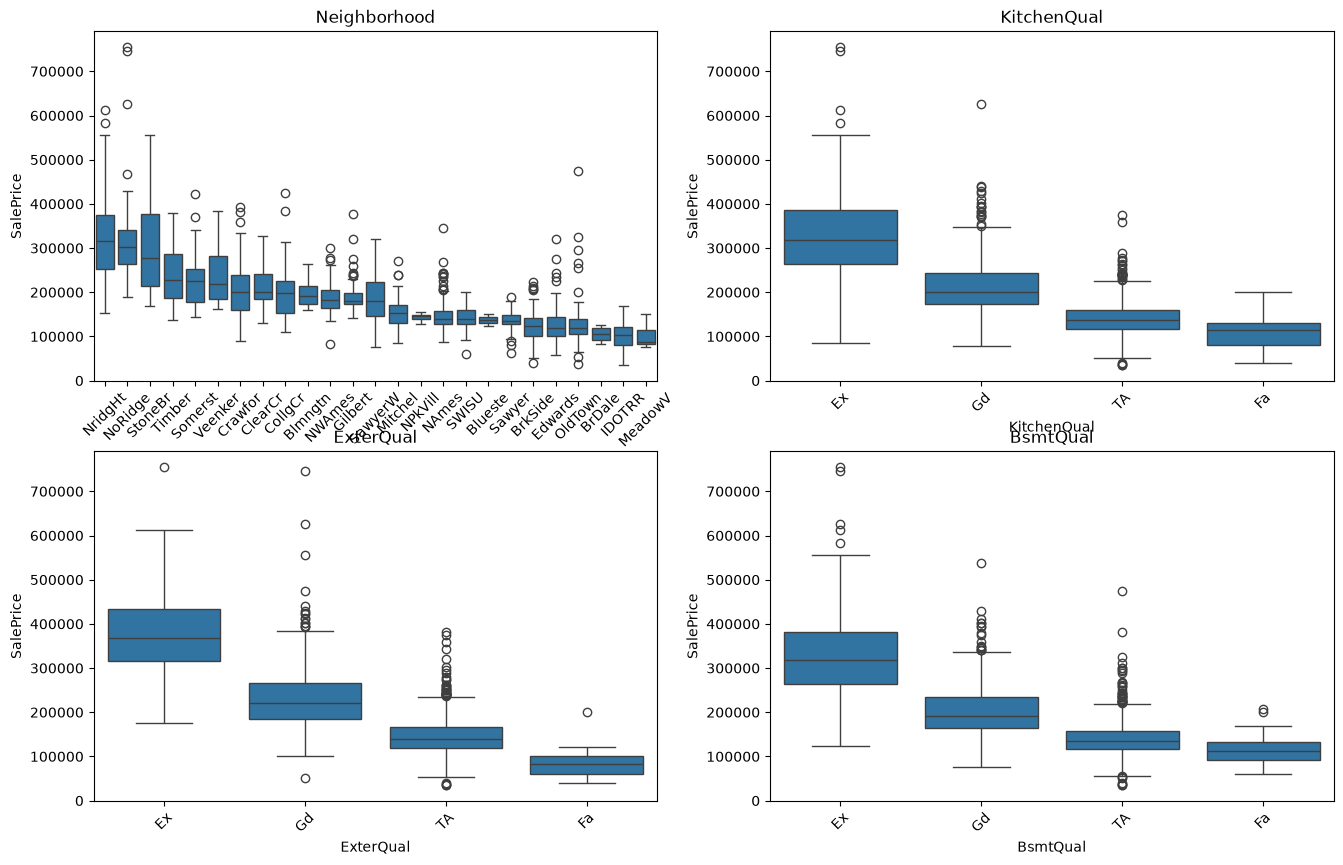

In [17]:
cat_features = ['Neighborhood', 'KitchenQual', 'ExterQual', 'BsmtQual']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    order = train.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='SalePrice', order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

ВЫВОДЫ ПО EDA:

1. OverallQual - самая сильная фича, корреляция +0.79 с SalePrice - чем выше качество материалов и отделки, тем дороже дом
2. GrLivArea - вторая по силе фича, корреляция +0.71 - жилая площадь прямо влияет на цену, удалили 2 выброса (большая площадь но низкая цена)
3. GarageCars и GarageArea - корреляция 0.64 и 0.62, но это фактически одно и то же
4. TotalBsmtSF и 1stFlrSF - корреляция 0.61, математически связаны между собой
5. Neighborhood - номинальный признак но очень сильный, разброс цен между районами в 3-4 раза
6. KitchenQual, ExterQual, BsmtQual - порядковые признаки (Ex/Gd/TA/Fa/Po)
7. MSSubClass - хранится как int64 но по сути категориальный (коды типов домов)
8. SalePrice правоскошенный - обучаем на log1p(SalePrice), в конце expm1
9. PoolQC, Alley, Fence, FireplaceQu, все гаражные и подвальные колонки - NaN означает "нет объекта", заменяем на "None"
10. LotFrontage - 259 пропусков
11. MasVnrArea - 8 пропусков, Electrical - 1 пропуск